# Cantilever SHM — Improved Model (v2)
Fixes: removes duplicate features, clips outliers, adds engineered features, tunes hyperparameters, soft-vote ensemble, binary fallback.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'pandas', 'numpy', 'scikit-learn', 'joblib',
    'matplotlib', 'seaborn', 'xgboost'], check=True, capture_output=True)
print('OK')

OK


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
print('Imports OK')

Imports OK


In [3]:
# ── 1. Load — drop leaky columns only ────────────────────────────────────────
CSV_PATH = 'cantilever_features.csv'  # change path if needed
df = pd.read_csv(CSV_PATH)
df = df.drop(columns=['sample_id', 'session', 'damage_level']).dropna()

label_order = ['Healthy', 'Light Damage', 'Moderate Damage', 'Severe Damage']
le = LabelEncoder()
le.fit(label_order)

print('Shape:', df.shape)
print('Class distribution:')
print(df['damage_label'].value_counts())

Shape: (1438, 20)
Class distribution:
damage_label
Light Damage       360
Moderate Damage    360
Healthy            359
Severe Damage      359
Name: count, dtype: int64


In [4]:
# ── 2. DIAGNOSE: RMS vs Std ───────────────────────────────────────────────────
print('RMS == Std (identical)?', (df['RMS'] == df['Std']).all())
print('Correlation RMS vs Std:', df['RMS'].corr(df['Std']))
print('Natural_Freq value counts (top 5):')
print(df['Natural_Freq'].value_counts().head())
print('Kurtosis max:', df['Kurtosis'].max(), '| 99th pct:', df['Kurtosis'].quantile(0.99))

RMS == Std (identical)? True
Correlation RMS vs Std: 1.0
Natural_Freq value counts (top 5):
Natural_Freq
5.0     1189
5.5       16
6.0       13
46.5      11
1.0       10
Name: count, dtype: int64
Kurtosis max: 165.2351 | 99th pct: 64.99432399999996


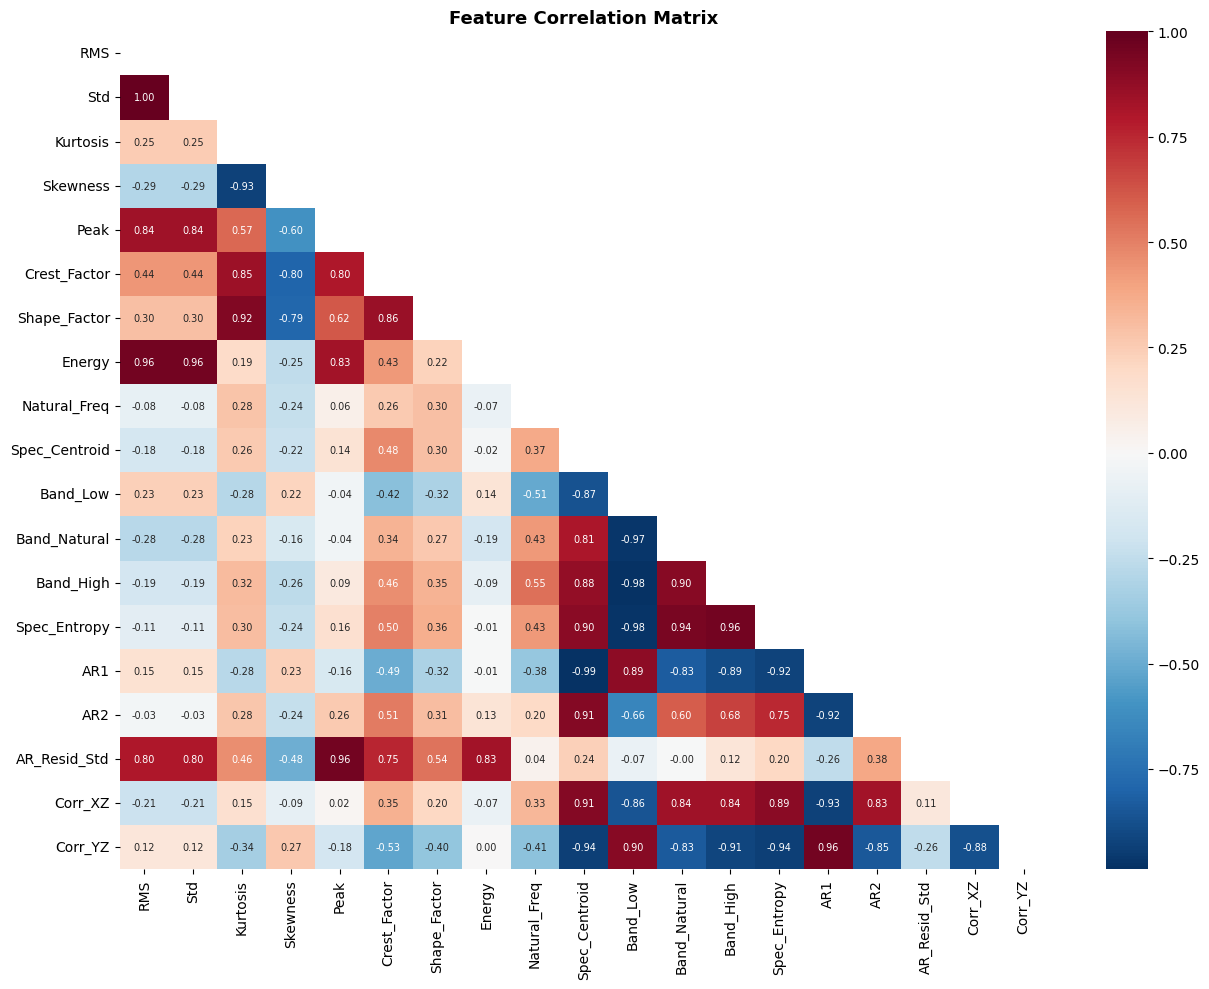

High correlations (>0.90):
  RMS <-> Std: 1.0000
  RMS <-> Energy: 0.9595
  Std <-> Energy: 0.9595
  Kurtosis <-> Skewness: -0.9286
  Kurtosis <-> Shape_Factor: 0.9154
  Peak <-> AR_Resid_Std: 0.9576
  Spec_Centroid <-> AR1: -0.9882
  Spec_Centroid <-> AR2: 0.9117
  Spec_Centroid <-> Corr_XZ: 0.9125
  Spec_Centroid <-> Corr_YZ: -0.9396
  Band_Low <-> Band_Natural: -0.9663
  Band_Low <-> Band_High: -0.9823
  Band_Low <-> Spec_Entropy: -0.9755
  Band_Low <-> Corr_YZ: 0.9009
  Band_Natural <-> Band_High: 0.9018
  Band_Natural <-> Spec_Entropy: 0.9405
  Band_High <-> Spec_Entropy: 0.9604
  Band_High <-> Corr_YZ: -0.9127
  Spec_Entropy <-> AR1: -0.9249
  Spec_Entropy <-> Corr_YZ: -0.9355
  AR1 <-> AR2: -0.9229
  AR1 <-> Corr_XZ: -0.9294
  AR1 <-> Corr_YZ: 0.9553


In [5]:
# ── 3. DIAGNOSE: Feature correlation heatmap ──────────────────────────────────
signal_feats = ['RMS','Std','Kurtosis','Skewness','Peak','Crest_Factor',
                'Shape_Factor','Energy','Natural_Freq','Spec_Centroid',
                'Band_Low','Band_Natural','Band_High','Spec_Entropy',
                'AR1','AR2','AR_Resid_Std','Corr_XZ','Corr_YZ']

fig, ax = plt.subplots(figsize=(13, 10))
corr = df[signal_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('High correlations (>0.90):')
for i, c1 in enumerate(signal_feats):
    for c2 in signal_feats[i+1:]:
        v = corr.loc[c1, c2]
        if abs(v) > 0.90:
            print(f'  {c1} <-> {c2}: {v:.4f}')

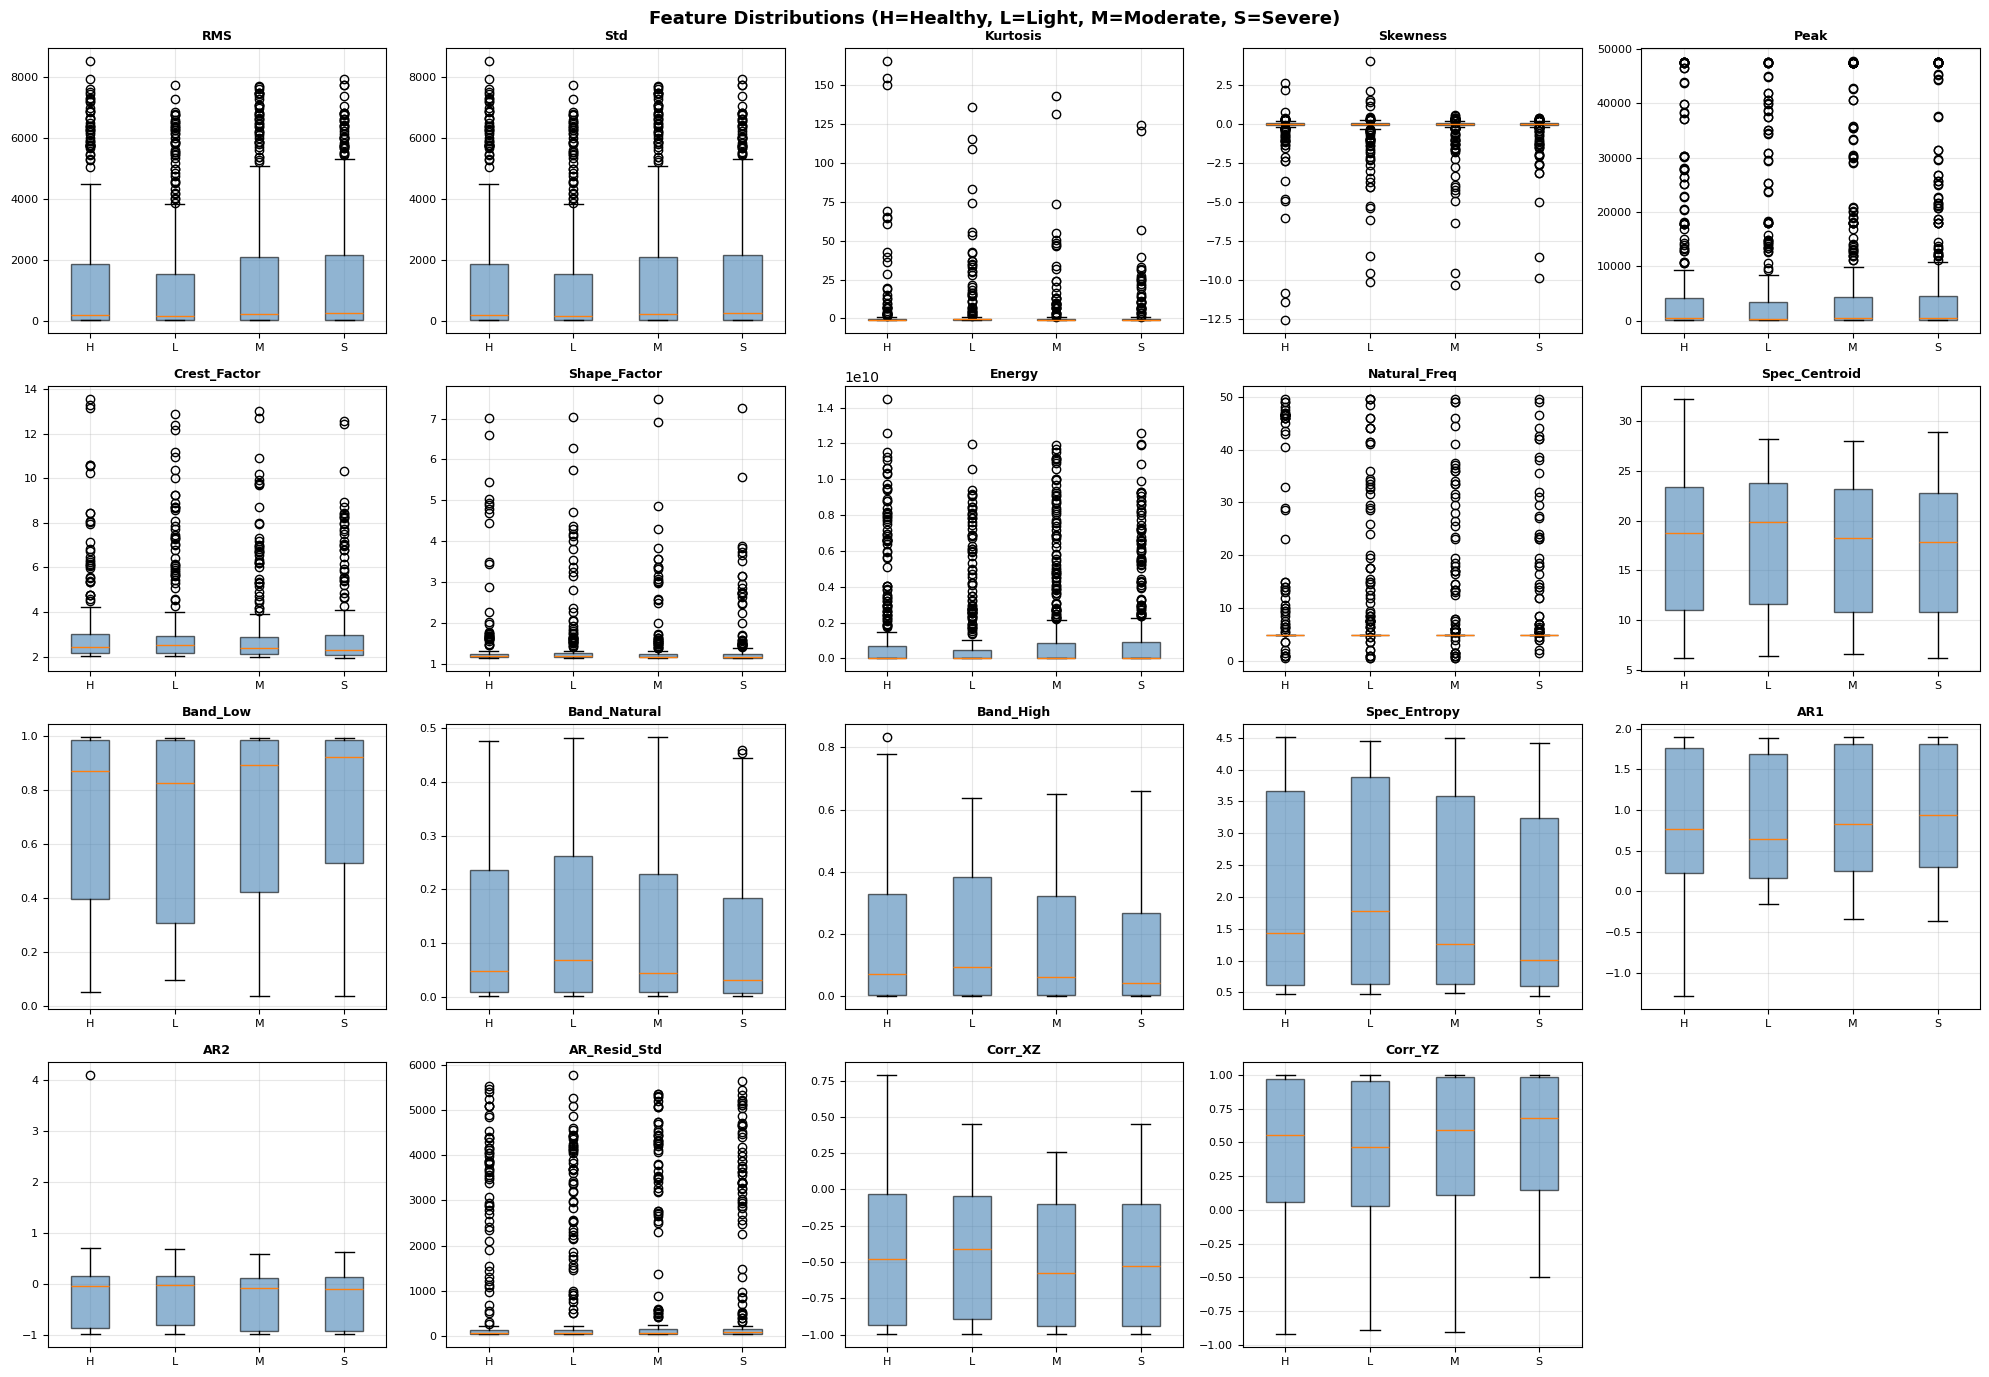

Boxes that do NOT overlap across groups = good discriminators.


In [6]:
# ── 4. DIAGNOSE: Box plots per class ─────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
for ax, feat in zip(axes.flat, signal_feats):
    data_by_class = [df[df['damage_label'] == lbl][feat].values for lbl in label_order]
    ax.boxplot(data_by_class, labels=['H','L','M','S'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes.flat[len(signal_feats):]:
    ax.set_visible(False)
plt.suptitle('Feature Distributions (H=Healthy, L=Light, M=Moderate, S=Severe)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxes that do NOT overlap across groups = good discriminators.')

In [7]:
# ── 5. Clean features ─────────────────────────────────────────────────────────
# Std == RMS (zero-mean signal), Energy and AR_Resid_Std also redundant with RMS
DROP_FEATURES = ['Std', 'Energy', 'AR_Resid_Std']
df_clean = df.drop(columns=DROP_FEATURES).copy()

# Clip outliers at 0.5th / 99.5th percentile
num_cols = df_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    lo = df_clean[col].quantile(0.005)
    hi = df_clean[col].quantile(0.995)
    df_clean[col] = df_clean[col].clip(lo, hi)

print('Features after dropping redundant cols:')
print([c for c in df_clean.columns if c != 'damage_label'])

Features after dropping redundant cols:
['RMS', 'Kurtosis', 'Skewness', 'Peak', 'Crest_Factor', 'Shape_Factor', 'Natural_Freq', 'Spec_Centroid', 'Band_Low', 'Band_Natural', 'Band_High', 'Spec_Entropy', 'AR1', 'AR2', 'Corr_XZ', 'Corr_YZ']


In [8]:
# ── 6. Feature engineering ────────────────────────────────────────────────────
df_clean['RMS_x_Kurtosis']  = df_clean['RMS'] * df_clean['Kurtosis'].abs()
df_clean['Crest_x_Shape']   = df_clean['Crest_Factor'] * df_clean['Shape_Factor']
df_clean['Freq_x_Entropy']  = df_clean['Natural_Freq'] * df_clean['Spec_Entropy']
df_clean['Band_ratio']      = df_clean['Band_High'] / (df_clean['Band_Low'] + 1e-6)
df_clean['AR_diff']         = df_clean['AR1'] - df_clean['AR2']
df_clean['Corr_combined']   = df_clean['Corr_XZ'].abs() + df_clean['Corr_YZ'].abs()
df_clean['Peak_over_RMS']   = df_clean['Peak'] / (df_clean['RMS'] + 1e-6)

final_features = [c for c in df_clean.columns if c != 'damage_label']
print(f'Total features: {len(final_features)}')
print(final_features)

Total features: 23
['RMS', 'Kurtosis', 'Skewness', 'Peak', 'Crest_Factor', 'Shape_Factor', 'Natural_Freq', 'Spec_Centroid', 'Band_Low', 'Band_Natural', 'Band_High', 'Spec_Entropy', 'AR1', 'AR2', 'Corr_XZ', 'Corr_YZ', 'RMS_x_Kurtosis', 'Crest_x_Shape', 'Freq_x_Entropy', 'Band_ratio', 'AR_diff', 'Corr_combined', 'Peak_over_RMS']


In [9]:
# ── 7. Train / test split ─────────────────────────────────────────────────────
y = le.transform(df_clean['damage_label'])
X = df_clean[final_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

Train: (1150, 23) | Test: (288, 23)


In [10]:
# ── 8. Hyperparameter tuning — XGBoost ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.02, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42, verbosity=0)
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=cv, scoring='accuracy',
                        n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_s, y_train)
print('Best XGB params:', xgb_grid.best_params_)
print('Best XGB CV accuracy:', round(xgb_grid.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best XGB CV accuracy: 0.3852


In [11]:
# ── 9. Hyperparameter tuning — Random Forest ──────────────────────────────────
rf_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [None, 8, 15],
    'min_samples_leaf': [1, 3, 5],
    'max_features':     ['sqrt', 'log2'],
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=cv, scoring='accuracy',
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train_s, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV accuracy:', round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
Best RF CV accuracy: 0.373


In [12]:
# ── 10. Soft-vote ensemble ────────────────────────────────────────────────────
best_xgb = xgb_grid.best_estimator_
best_rf  = rf_grid.best_estimator_

ensemble = VotingClassifier(
    estimators=[('xgb', best_xgb), ('rf', best_rf)],
    voting='soft'
)
ensemble.fit(X_train_s, y_train)

results = {}
for name, mdl in [('XGBoost (tuned)', best_xgb),
                   ('Random Forest (tuned)', best_rf),
                   ('Ensemble (soft vote)', ensemble)]:
    pred = mdl.predict(X_test_s)
    acc  = accuracy_score(y_test, pred)
    results[name] = (mdl, pred, acc)
    print(f'{name:<28}  Test Accuracy: {acc:.4f}')

XGBoost (tuned)               Test Accuracy: 0.3819
Random Forest (tuned)         Test Accuracy: 0.3576
Ensemble (soft vote)          Test Accuracy: 0.3715


In [13]:
# ── 11. Best model — full report ──────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k][2])
best_model, y_pred, test_acc = results[best_name]
print(f'Best: {best_name}  ->  {test_acc:.2%}\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best: XGBoost (tuned)  ->  38.19%

                 precision    recall  f1-score   support

        Healthy       0.40      0.32      0.36        72
   Light Damage       0.43      0.44      0.44        72
Moderate Damage       0.33      0.33      0.33        72
  Severe Damage       0.37      0.43      0.40        72

       accuracy                           0.38       288
      macro avg       0.38      0.38      0.38       288
   weighted avg       0.38      0.38      0.38       288



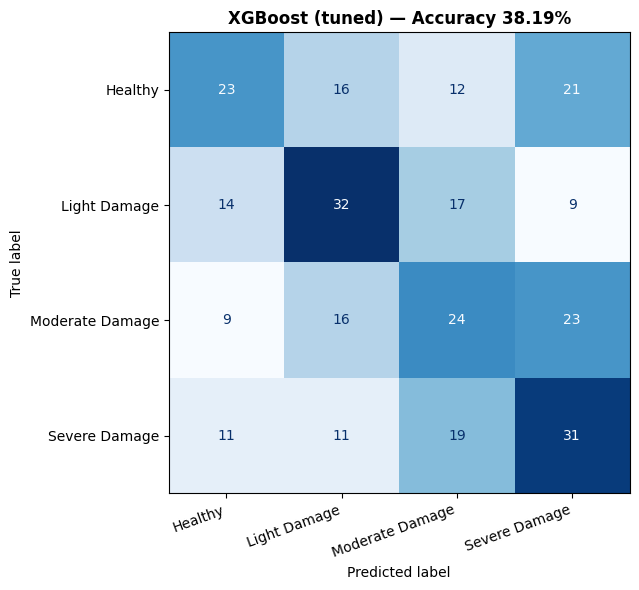

In [14]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_name} — Accuracy {test_acc:.2%}', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

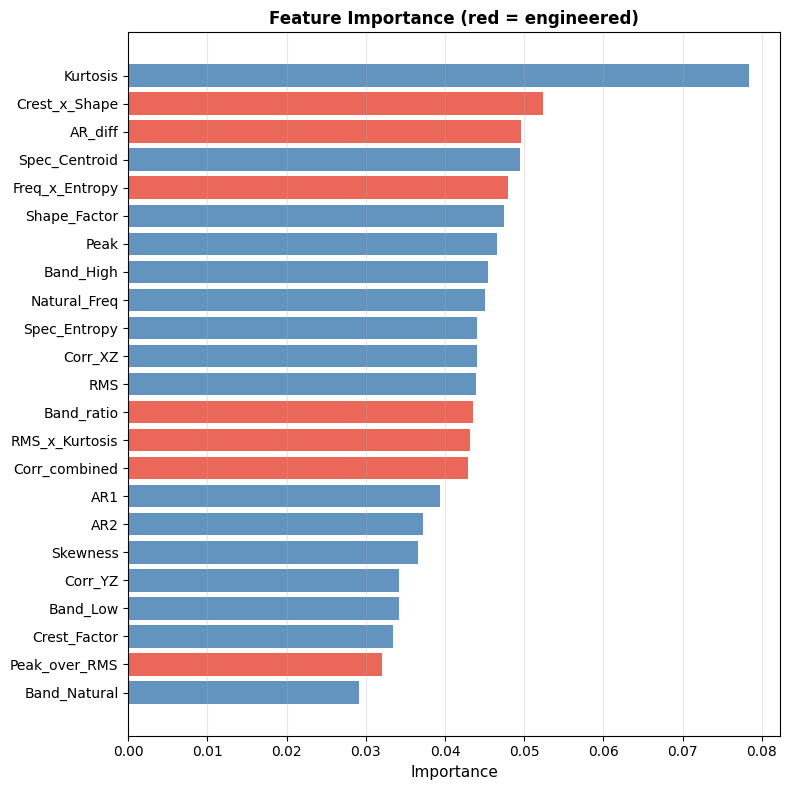

Top 8:
       Feature  Importance
      Kurtosis    0.078386
 Crest_x_Shape    0.052403
       AR_diff    0.049656
 Spec_Centroid    0.049452
Freq_x_Entropy    0.047998
  Shape_Factor    0.047405
          Peak    0.046507
     Band_High    0.045378


In [15]:
# ── 13. Feature importance ────────────────────────────────────────────────────
tree_mdl = best_xgb if hasattr(best_xgb, 'feature_importances_') else best_rf
imp = pd.DataFrame({'Feature': final_features,
                    'Importance': tree_mdl.feature_importances_})\
        .sort_values('Importance', ascending=True)

engineered = {'RMS_x_Kurtosis','Crest_x_Shape','Freq_x_Entropy',
              'Band_ratio','AR_diff','Corr_combined','Peak_over_RMS'}
colors = ['#e74c3c' if f in engineered else 'steelblue' for f in imp['Feature']]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(imp['Feature'], imp['Importance'], color=colors, alpha=0.85)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Feature Importance (red = engineered)', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 8:')
print(imp.sort_values('Importance', ascending=False).head(8).to_string(index=False))

In [16]:
# ── 14. Binary model: Healthy vs Any Damage ───────────────────────────────────
y_bin_train = (y_train > 0).astype(int)
y_bin_test  = (y_test  > 0).astype(int)

bin_model = GradientBoostingClassifier(n_estimators=300, max_depth=4,
                                       learning_rate=0.05, random_state=42)
bin_model.fit(X_train_s, y_bin_train)
bin_pred = bin_model.predict(X_test_s)
bin_acc  = accuracy_score(y_bin_test, bin_pred)
print(f'Binary (Healthy vs Damaged) accuracy: {bin_acc:.2%}')
print(classification_report(y_bin_test, bin_pred,
      target_names=['Healthy', 'Any Damage']))

Binary (Healthy vs Damaged) accuracy: 75.69%
              precision    recall  f1-score   support

     Healthy       0.56      0.12      0.20        72
  Any Damage       0.77      0.97      0.86       216

    accuracy                           0.76       288
   macro avg       0.67      0.55      0.53       288
weighted avg       0.72      0.76      0.69       288



In [17]:
# ── 15. Save artefacts ────────────────────────────────────────────────────────
joblib.dump(best_model,     'shm_model_v2.pkl')
joblib.dump(scaler,         'scaler_v2.pkl')
joblib.dump(le,             'label_encoder_v2.pkl')
joblib.dump(final_features, 'features_v2.pkl')
joblib.dump(bin_model,      'shm_binary_model.pkl')

print('Saved: shm_model_v2.pkl, scaler_v2.pkl, label_encoder_v2.pkl, features_v2.pkl, shm_binary_model.pkl')
print()
print('=' * 50)
print(f'  Best model       : {best_name}')
print(f'  4-class accuracy : {test_acc:.2%}')
print(f'  Binary accuracy  : {bin_acc:.2%}')
print('=' * 50)

Saved: shm_model_v2.pkl, scaler_v2.pkl, label_encoder_v2.pkl, features_v2.pkl, shm_binary_model.pkl

  Best model       : XGBoost (tuned)
  4-class accuracy : 38.19%
  Binary accuracy  : 75.69%
